# Analysis of the Ordinal-APS results for the LLama model

# First analysis: Are the prediction sets leaning to the correct veracity label?

### We consider that 'true', 'mostly-true', 'half-true' into the true category and 'mostly-false', 'false' and 'pants-fire' into the false category

We want to see if a prediction set have more true labels and false labels and to see if the label of the statement corresponds into the same category as the majority of the statements

In [1]:
import pandas as pd
import ast

true_side_labels = {"true", "mostly-true", "half-true"}
false_side_labels = {"mostly-false", "false", "pants-fire"}

def verdict_side(verdict):
    if verdict in true_side_labels:
        return "true"
    if verdict in false_side_labels:
        return "false"
    return "unknown"

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def prediction_set_side(prediction_set):
    labels = parse_prediction_set(prediction_set)
    true_count = sum(label in true_side_labels for label in labels)
    false_count = sum(label in false_side_labels for label in labels)

    if true_count > false_count:
        return "true"
    if false_count > true_count:
        return "false"
    return "neutral"

def check_prediction_set(df):
    df["true_side"] = df["true_verdict"].apply(verdict_side)
    df["prediction_side"] = df["prediction_set"].apply(prediction_set_side)

    df["side_matches"] = df["prediction_side"] == df["true_side"]
    df["is_neutral"] = df["prediction_side"] == "neutral"

    total_rows = len(df)
    match_rate_all = df["side_matches"].mean()
    neutral_rate = df["is_neutral"].mean()

    non_neutral = df[~df["is_neutral"]]
    match_rate_non_neutral = non_neutral["side_matches"].mean() if len(non_neutral) else float("nan")

    print(f"Rows: {total_rows}")
    print(f"Prediction sets leaning to the correct side: {df['side_matches'].sum()} / {total_rows}")
    print(f"Match rate including neutral sets: {match_rate_all:.3f}")
    print(f"Neutral rate: {neutral_rate:.3f}")
    print(f"Match rate excluding neutral sets: {match_rate_non_neutral:.3f}")

    # Optional: show a few examples
    df[["true_verdict", "prediction_set", "true_side", "prediction_side", "side_matches"]].head(10)

## Gather the results for no evidence and evidence 

### Show for each category how are the prediction sets leaning to 

In [2]:
no_evidence_ordinalaps_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/crime/conformal_results_ordinal_aps_all_trials_100trials_20260424_064720.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/economy/conformal_results_ordinal_aps_all_trials_100trials_20260424_083456.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/education/conformal_results_ordinal_aps_all_trials_100trials_20260424_073035.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/elections/conformal_results_ordinal_aps_all_trials_100trials_20260424_083008.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260424_114328.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260424_104754.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260424_105512.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260424_113144.csv"
}

with_evidence_ordinalaps_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/crime/conformal_results_ordinal_aps_all_trials_100trials_20260505_161238.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/economy/conformal_results_ordinal_aps_all_trials_100trials_20260509_061650.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/education/conformal_results_ordinal_aps_all_trials_100trials_20260509_031418.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/elections/conformal_results_ordinal_aps_all_trials_100trials_20260505_210920.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260505_230716.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260505_181447.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260505_164257.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-ordinal-aps-evidence/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260507_175239.csv"
}

for category in no_evidence_ordinalaps_llama_csv.keys():
    print(f"Category: {category}")
    print("Without evidence:")
    df_no_evidence = pd.read_csv(no_evidence_ordinalaps_llama_csv[category])
    check_prediction_set(df_no_evidence)
    
    print("\nWith evidence:")
    df_with_evidence = pd.read_csv(with_evidence_ordinalaps_llama_csv[category])
    check_prediction_set(df_with_evidence)
    
    print("\n" + "="*50 + "\n")

Category: crime
Without evidence:
Rows: 55000
Prediction sets leaning to the correct side: 34532 / 55000
Match rate including neutral sets: 0.628
Neutral rate: 0.082
Match rate excluding neutral sets: 0.684

With evidence:
Rows: 55000
Prediction sets leaning to the correct side: 44509 / 55000
Match rate including neutral sets: 0.809
Neutral rate: 0.133
Match rate excluding neutral sets: 0.933


Category: economy
Without evidence:
Rows: 97800
Prediction sets leaning to the correct side: 61749 / 97800
Match rate including neutral sets: 0.631
Neutral rate: 0.071
Match rate excluding neutral sets: 0.680

With evidence:
Rows: 97800
Prediction sets leaning to the correct side: 78532 / 97800
Match rate including neutral sets: 0.803
Neutral rate: 0.102
Match rate excluding neutral sets: 0.894


Category: education
Without evidence:
Rows: 67600
Prediction sets leaning to the correct side: 40739 / 67600
Match rate including neutral sets: 0.603
Neutral rate: 0.065
Match rate excluding neutral set

In [10]:
"""
Visualize prediction-set evaluation results with and without evidence.

Produces four charts:
  1. Dumbbell chart       - lift from evidence per category
  2. 100% stacked bars    - correct / neutral / incorrect breakdown
  3. Scatter vs. y=x      - with-evidence vs. without-evidence accuracy
  4. Grouped bar chart    - simple side-by-side accuracy comparison
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Data (paste your numbers here, or compute them from your DataFrame)
# ---------------------------------------------------------------------------

results = {
    "crime":       {"without": (0.628, 0.082), "with": (0.809, 0.133)},
    "economy":     {"without": (0.631, 0.071), "with": (0.803, 0.102)},
    "education":   {"without": (0.603, 0.065), "with": (0.745, 0.151)},
    "elections":   {"without": (0.640, 0.108), "with": (0.812, 0.119)},
    "health-care": {"without": (0.603, 0.065), "with": (0.802, 0.118)},
    "immigration": {"without": (0.592, 0.136), "with": (0.751, 0.157)},
    "jobs":        {"without": (0.632, 0.049), "with": (0.800, 0.096)},
    "taxes":       {"without": (0.585, 0.081), "with": (0.788, 0.112)},
}

# Sort by size of lift (with - without) for a tidier dumbbell chart
categories = sorted(results.keys(),
                    key=lambda c: results[c]["with"][0] - results[c]["without"][0])

without_correct = np.array([results[c]["without"][0] for c in categories])
with_correct    = np.array([results[c]["with"][0]    for c in categories])
without_neutral = np.array([results[c]["without"][1] for c in categories])
with_neutral    = np.array([results[c]["with"][1]    for c in categories])
without_wrong   = 1 - without_correct - without_neutral
with_wrong      = 1 - with_correct - with_neutral

# Color palette
C_WITHOUT = "#d97757"   # warm orange
C_WITH    = "#3a7d7b"   # teal
C_CORRECT = "#3a7d7b"
C_NEUTRAL = "#c8c2b6"
C_WRONG   = "#d97757"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
})


# ---------------------------------------------------------------------------
# 2. 100% stacked bar chart
# ---------------------------------------------------------------------------
def stacked_bar_chart(path):
    fig, ax = plt.subplots(figsize=(11, 7))
    x = np.arange(len(categories))
    width = 0.38

    # Without evidence (left bar of each pair) — hatched
    ax.bar(x - width / 2, without_correct, width,
           color=C_CORRECT, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_neutral, width, bottom=without_correct,
           color=C_NEUTRAL, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_wrong, width,
           bottom=without_correct + without_neutral,
           color=C_WRONG, hatch="//", edgecolor="white")

    # With evidence (right bar of each pair) — solid
    ax.bar(x + width / 2, with_correct, width,
           color=C_CORRECT, edgecolor="white")
    ax.bar(x + width / 2, with_neutral, width, bottom=with_correct,
           color=C_NEUTRAL, edgecolor="white")
    ax.bar(x + width / 2, with_wrong, width,
           bottom=with_correct + with_neutral,
           color=C_WRONG, edgecolor="white")

    # numeric labels on the "correct" (teal) segment
    for xi, v in zip(x - width / 2, without_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v in zip(x + width / 2, with_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # numeric labels on the "incorrect" (orange) segment
    for xi, v_bot, v_wrong in zip(x - width / 2,
                                   without_correct + without_neutral,
                                   without_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v_bot, v_wrong in zip(x + width / 2,
                                   with_correct + with_neutral,
                                   with_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # "no ev." / "ev." sub-labels under each bar pair
    for xi in x:
        ax.text(xi - width / 2, -0.025, "no ev.", ha="center", va="top",
                fontsize=7.5, color="#666")
        ax.text(xi + width / 2, -0.025, "ev.",    ha="center", va="top",
                fontsize=7.5, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")

    # Title only at top
    fig.suptitle("Prediction outcome breakdown by category for Llama using Ordinal-APS",
                 fontsize=14, fontweight="bold", y=0.97)

    # Two legends below the x-axis (moved lower)
    outcome_handles = [
        plt.Rectangle((0, 0), 1, 1, color=C_CORRECT, label="Correct"),
        plt.Rectangle((0, 0), 1, 1, color=C_NEUTRAL, label="Neutral"),
        plt.Rectangle((0, 0), 1, 1, color=C_WRONG,   label="Incorrect"),
    ]
    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555",
                      hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555",
                      label="With evidence"),
    ]
    leg1 = ax.legend(handles=outcome_handles, title="Outcome",
                     loc="upper center", bbox_to_anchor=(0.30, -0.16),
                     ncol=3, frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=condition_handles, title="Condition",
              loc="upper center", bbox_to_anchor=(0.78, -0.16),
              ncol=2, frameon=False)

    # Description slightly lower to sit closer to legends
    # fig.text(
    #     0.5, 0.007,
    #     "We check whether each prediction set leans to the correct truth side (true vs. false).\n"
    #     "A prediction set leans 'correctly' when the majority of labels in the set are on the same truth side as the ground truth,\n"
    #     "'incorrectly' when the majority leans the opposite way, and 'neutral' when counts are tied.\n"
    #     "Left bar (hatched) = model WITHOUT evidence.   Right bar (solid) = model WITH evidence.",
    #     ha="center", va="top", fontsize=12.0, color="#444",
    # )

    plt.tight_layout(rect=[0, 0.00, 1, 0.94])
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
if __name__ == "__main__":

    stacked_bar_chart("visualisations_OrdinalAPS/stacked_bar_ordinalaps.png")
    print("Saved: visualisations_OrdinalAPS/stacked_bar_ordinalaps.png")

Saved: visualisations_OrdinalAPS/stacked_bar_ordinalaps.png


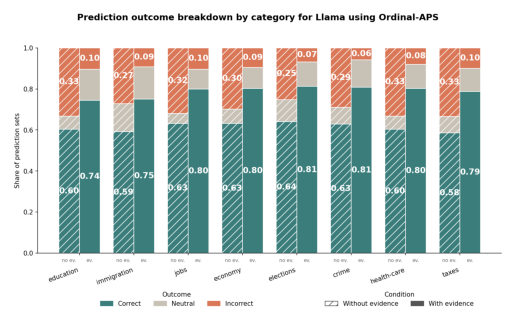

In [11]:
# Display the stacked bar

import matplotlib.pyplot as plt
img = plt.imread("visualisations_OrdinalAPS/stacked_bar_ordinalaps.png")
plt.imshow(img); plt.axis("off"); plt.show()


# Conclusion from the first analysis:

# Second analysis: What are the distribution for each of the prediction set size (e.g., 1,2,3,4,5,6)?
### For each category, we will see the distribution of each prediction set sizes (how many are of size 1, 2, 3, 4, 5 and 6)

While not visible in the chart, the elections and immigration have 39 and 5 6-label prediction sets, and the rest have 0.

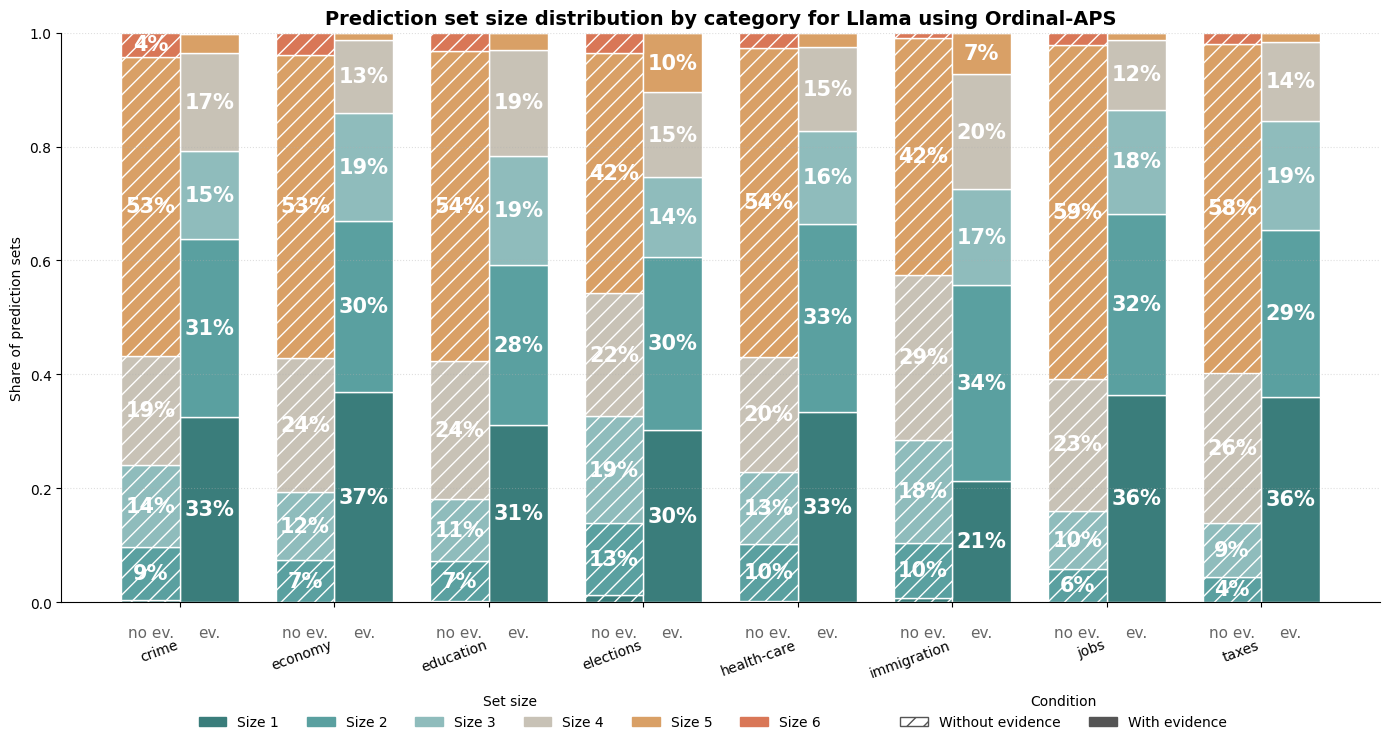

Saved: visualisations_OrdinalAPS/set_size_distribution_ordinalaps.png


In [9]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df

def get_size_percentages(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    counts = df["set_size"].value_counts().reindex([1, 2, 3, 4, 5, 6], fill_value=0)
    return counts / counts.sum()

def plot_all_categories_set_sizes(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv, output_path="visualisations_OrdinalAPS/set_size_distribution_ordinalaps.png"):
    categories = list(no_evidence_ordinalaps_llama_csv.keys())
    sizes = [1, 2, 3, 4, 5, 6]

    no_data = {cat: get_size_percentages(no_evidence_ordinalaps_llama_csv[cat]) for cat in categories}
    with_data = {cat: get_size_percentages(with_evidence_ordinalaps_llama_csv[cat]) for cat in categories}

    colors = ["#3a7d7b", "#5aa0a0", "#8fbcbc", "#c8c2b6", "#d9a066", "#d97757"]

    x = np.arange(len(categories))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 8))

    for i, size in enumerate(sizes):
        no_bottom = np.array([sum(no_data[cat].iloc[:i]) for cat in categories])
        with_bottom = np.array([sum(with_data[cat].iloc[:i]) for cat in categories])

        no_vals = np.array([no_data[cat].iloc[i] for cat in categories])
        with_vals = np.array([with_data[cat].iloc[i] for cat in categories])

        ax.bar(
            x - width / 2,
            no_vals,
            width,
            bottom=no_bottom,
            color=colors[i],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width / 2,
            with_vals,
            width,
            bottom=with_bottom,
            color=colors[i],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width / 2, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width / 2, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

    for xi in x:
        ax.text(xi - width / 2, -0.04, "no ev.", ha="center", va="top", fontsize=11, color="#666")
        ax.text(xi + width / 2, -0.04, "ev.", ha="center", va="top", fontsize=11, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")
    ax.set_title("Prediction set size distribution by category for Llama using Ordinal-APS", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    size_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i], label=f"Size {sizes[i]}")
        for i in range(len(sizes))
    ]

    leg1 = ax.legend(
        handles=size_handles,
        title="Set size",
        loc="upper center",
        bbox_to_anchor=(0.34, -0.14),
        ncol=6,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=condition_handles,
        title="Condition",
        loc="upper center",
        bbox_to_anchor=(0.76, -0.14),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_all_categories_set_sizes(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv, output_path="visualisations_OrdinalAPS/set_size_distribution_ordinalaps.png")
print("Saved: visualisations_OrdinalAPS/set_size_distribution_ordinalaps.png")

# Conclusion from the second analysis:

# Third analysis: What were the true label of the statements whose prediction set did not include it?

### Look for each of the failed prediction sets what should have them include

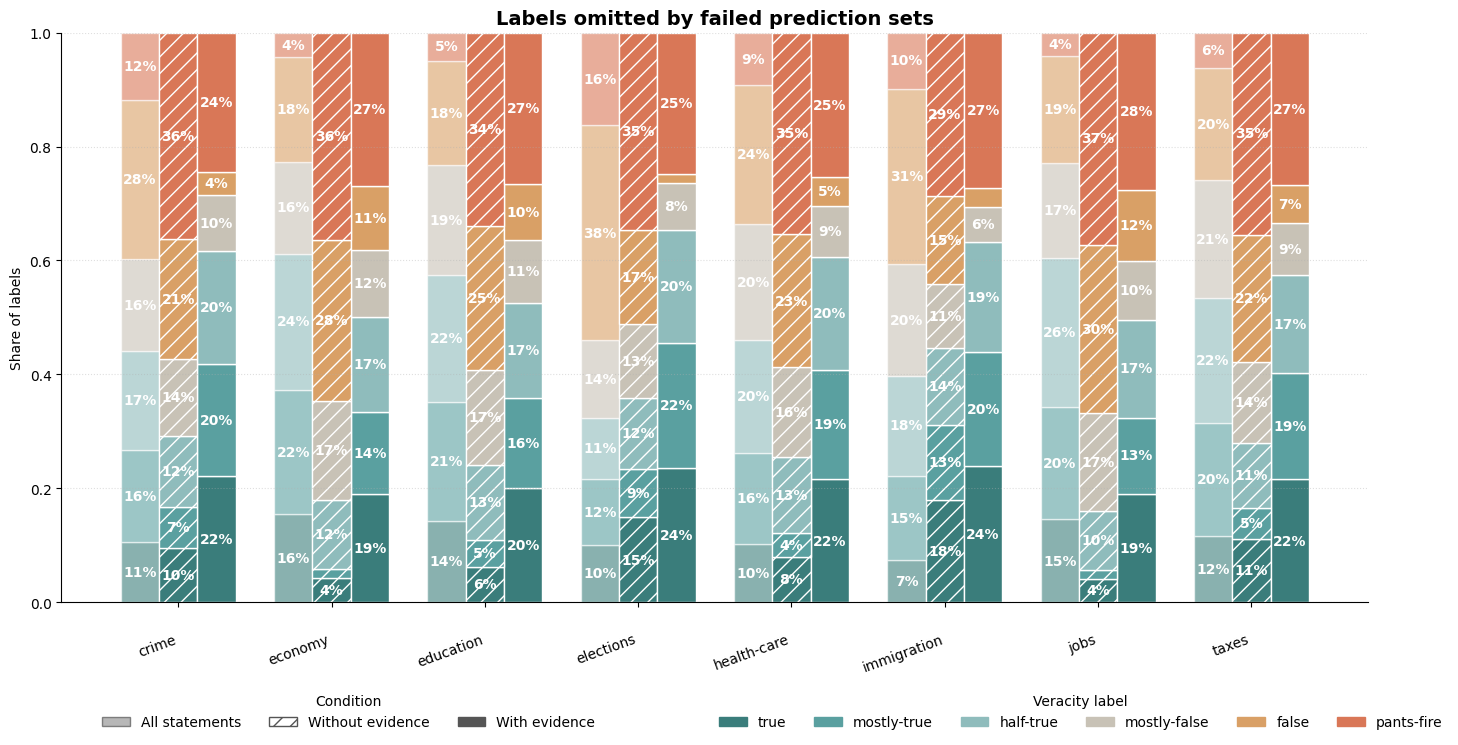

Saved: visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps.png


In [6]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv, output_path="visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps.png"):
    categories = list(no_evidence_ordinalaps_llama_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_ordinalaps_llama_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_ordinalaps_llama_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_ordinalaps_llama_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv, output_path="visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps.png")
print("Saved: visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps.png")

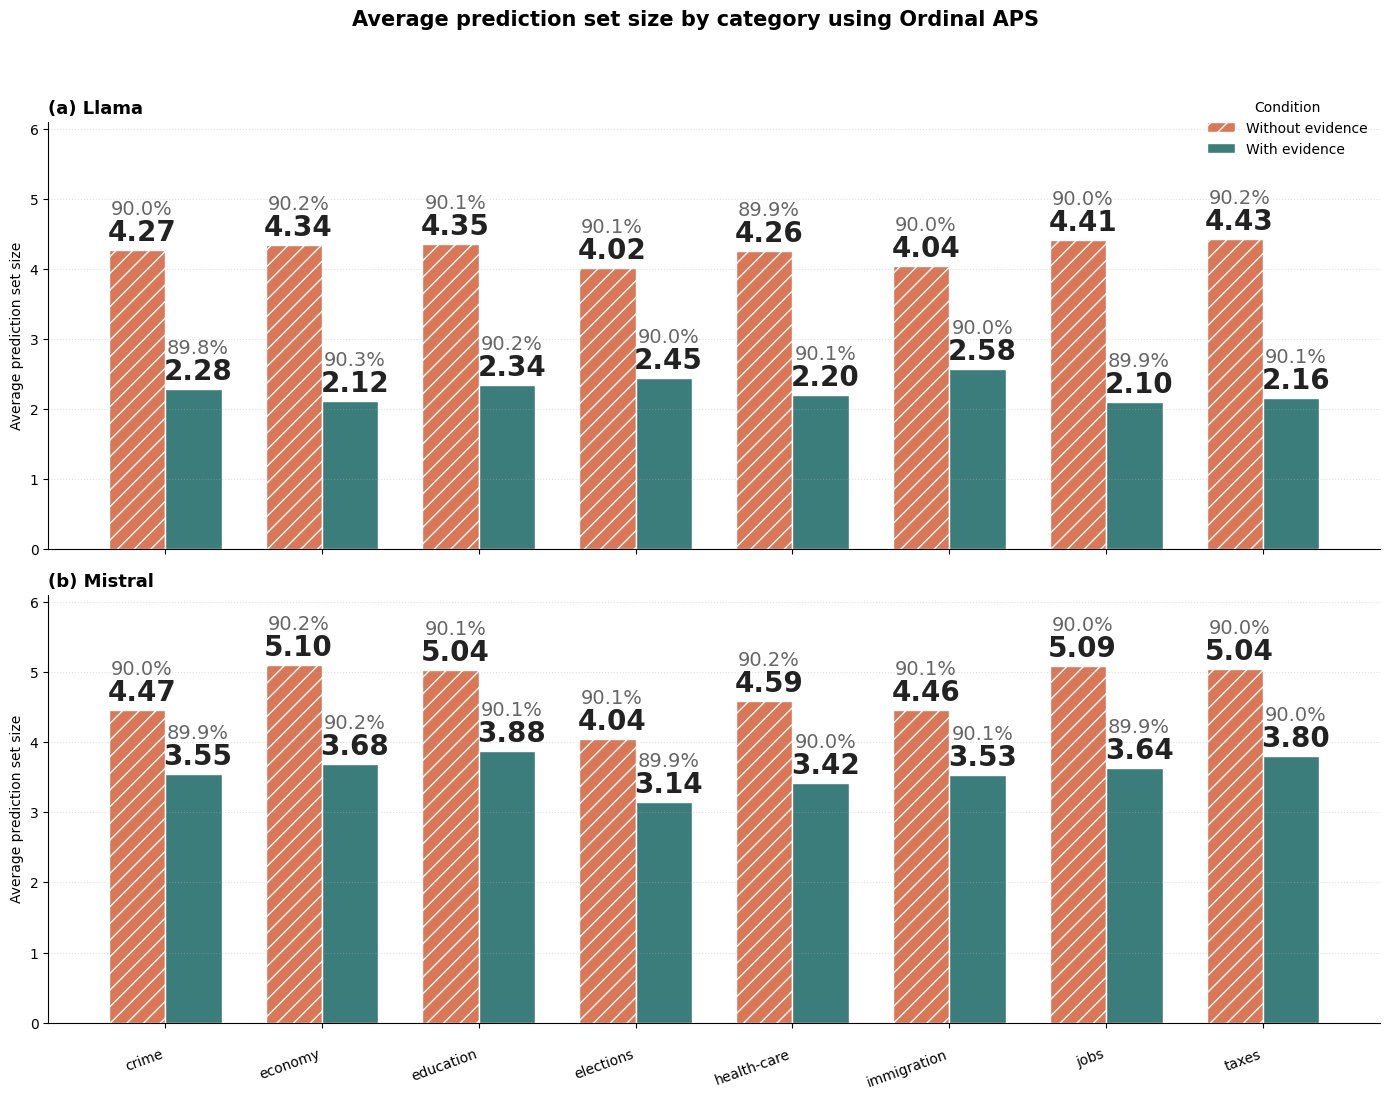

Saved: visualisations_OrdinalAPS/average_prediction_set_sizes_llama_ordinalaps.png


In [7]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

no_evidence_ordinalaps_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/crime/conformal_results_ordinal_aps_all_trials_100trials_20260424_070123.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/economy/conformal_results_ordinal_aps_all_trials_100trials_20260424_082637.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/education/conformal_results_ordinal_aps_all_trials_100trials_20260424_073118.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/elections/conformal_results_ordinal_aps_all_trials_100trials_20260424_082351.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260424_115129.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260424_104349.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260424_123810.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260424_112451.csv"
}

with_evidence_ordinalaps_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/crime/conformal_results_ordinal_aps_all_trials_100trials_20260507_143631.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/economy/conformal_results_ordinal_aps_all_trials_100trials_20260507_204034.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/education/conformal_results_ordinal_aps_all_trials_100trials_20260507_170836.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/elections/conformal_results_ordinal_aps_all_trials_100trials_20260507_202047.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/health-care/conformal_results_ordinal_aps_all_trials_100trials_20260507_221705.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/immigration/conformal_results_ordinal_aps_all_trials_100trials_20260509_043122.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/jobs/conformal_results_ordinal_aps_all_trials_100trials_20260507_152533.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-ordinal-aps-evidence/taxes/conformal_results_ordinal_aps_all_trials_100trials_20260507_184816.csv"
}





def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value


def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df


def get_average_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    avg_set_size = df["set_size"].mean()
    avg_coverage = df["is_covered"].mean()  # <-- change column name if yours differs
    return avg_set_size, avg_coverage


def _plot_model_panel(ax, categories, no_sizes, with_sizes, no_covs, with_covs,
                      title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_sizes,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_sizes,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, size_val, cov_val):
        ax.text(xi + 0.03, size_val + 0.05, f"{size_val:.2f}",
                ha="center", va="bottom", fontsize=20, fontweight="bold", color="#222")
        ax.text(xi + 0.03, size_val + 0.45, f"{cov_val * 100:.1f}%",
                ha="center", va="bottom", fontsize=14, color="#666")

    for xi, s, c in zip(x - width / 2, no_sizes, no_covs):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_sizes, with_covs):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average prediction set size")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                loc="upper right", bbox_to_anchor=(1.0, 1.08))


def plot_average_prediction_set_sizes(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
    output_path="visualisations_OrdinalAPS/average_prediction_set_sizes_llama_ordinalaps.png",
):
    categories = list(no_evidence_ordinalaps_llama_csv.keys())

    def gather(csv_dict):
        sizes, covs = [], []
        for c in categories:
            s, cov = get_average_metrics(csv_dict[c])
            sizes.append(s)
            covs.append(cov)
        return np.array(sizes), np.array(covs)

    llama_no_s, llama_no_c = gather(no_evidence_ordinalaps_llama_csv)
    llama_w_s, llama_w_c = gather(with_evidence_ordinalaps_llama_csv)
    mist_no_s, mist_no_c = gather(no_evidence_ordinalaps_mistral_csv)
    mist_w_s, mist_w_c = gather(with_evidence_ordinalaps_mistral_csv)

    # Shared y-limit so the two panels are directly comparable
    # Extra headroom (+1.0) so the stacked size + coverage labels don't get clipped
    y_max = max(llama_no_s.max(), llama_w_s.max(),
                mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_model_panel(ax_top, categories, llama_no_s, llama_w_s, llama_no_c, llama_w_c,
                      title="(a) Llama", show_legend=True, show_xticklabels=False)
    _plot_model_panel(ax_bot, categories, mist_no_s, mist_w_s, mist_no_c, mist_w_c,
                      title="(b) Mistral", show_legend=False, show_xticklabels=True)

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average prediction set size by category using Ordinal APS",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_average_prediction_set_sizes(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
)
print("Saved: visualisations_OrdinalAPS/average_prediction_set_sizes_llama_ordinalaps.png")


Llama - no evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        4.27           5.0           75.9%
    economy        4.34           5.0           80.7%
  education        4.35           5.0           82.0%
  elections        4.02           4.0           67.4%
health-care        4.26           5.0           77.1%
immigration        4.04           4.0           71.5%
       jobs        4.41           5.0           83.9%
      taxes        4.43           5.0           86.1%

Llama - with evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        2.28           2.0           20.8%
    economy        2.12           2.0           14.1%
  education        2.34           2.0           21.6%
  elections        2.45           2.0           25.4%
health-care        2.20           2.0           17.3%
immigration        2.58           2.0           27.5%
       jobs        2.10           2.0           13.5%
      taxes        2.16           2.0 

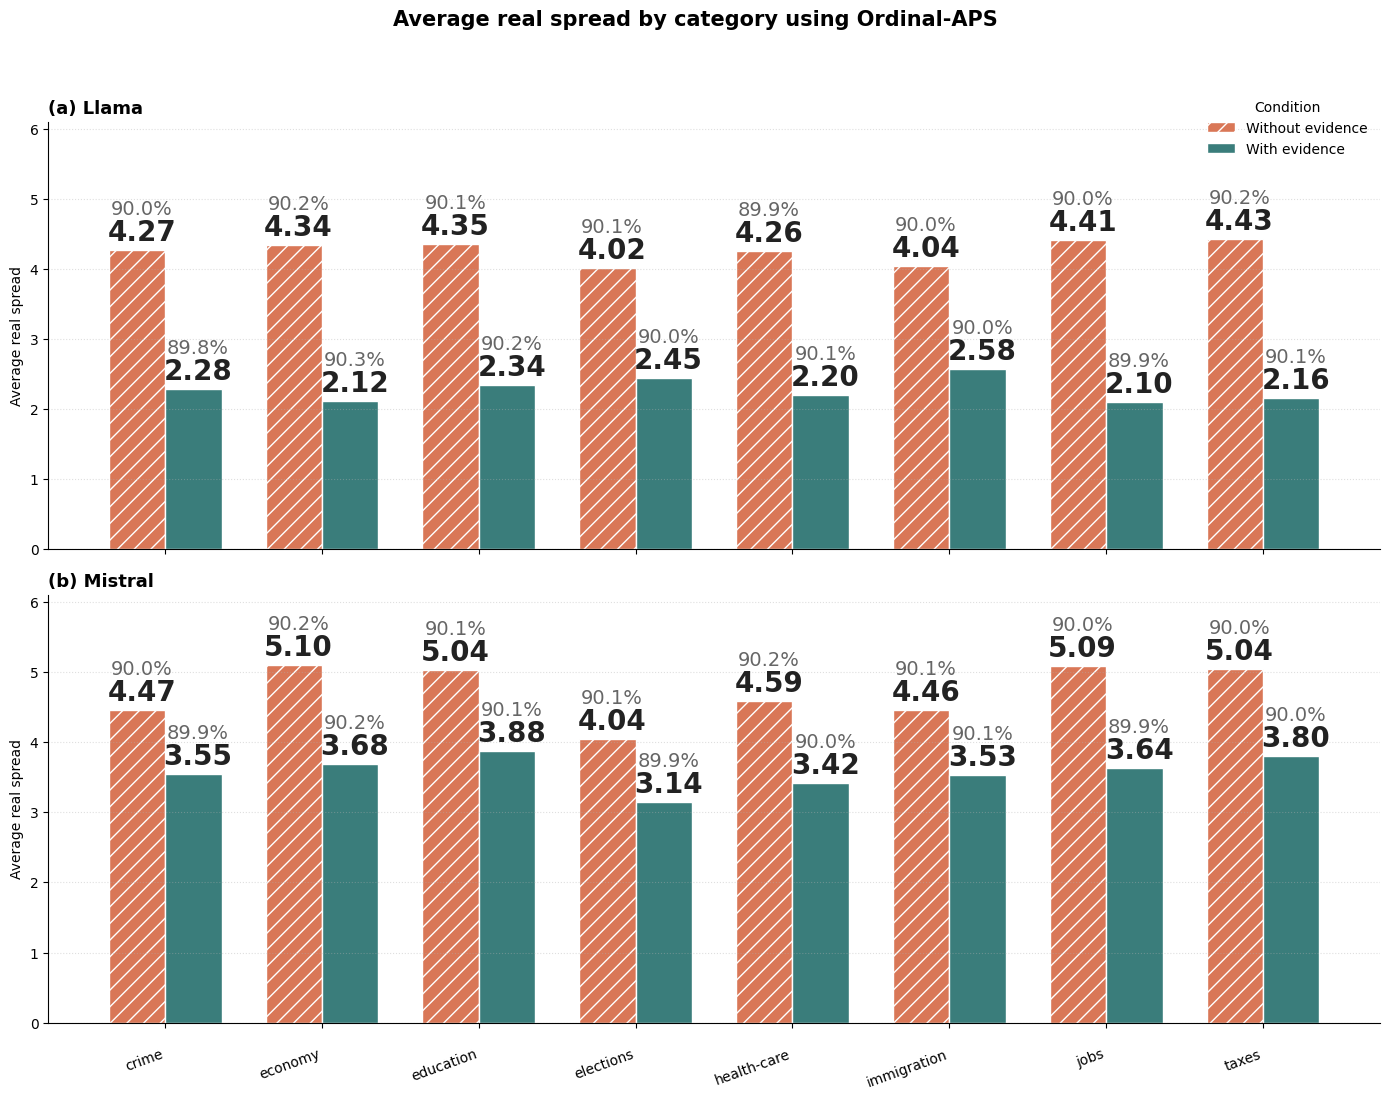

In [12]:
import ast
import pandas as pd
import numpy as np

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]
LABEL_TO_INDEX = {label: i for i, label in enumerate(LABEL_ORDER)}

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def real_spread(prediction_set):
    labels = parse_prediction_set(prediction_set)
    indices = [LABEL_TO_INDEX[l] for l in labels if l in LABEL_TO_INDEX]
    if not indices:
        return np.nan
    return (max(indices) - min(indices)) + 1  # inclusive span length

def add_spread(df):
    df = df.copy()
    df["real_spread"] = df["prediction_set"].apply(real_spread)
    return df

def summarize_spread(csv_dict, name):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "median_spread": df["real_spread"].median(),
            "pct_spread_ge_4": (df["real_spread"] >= 4).mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    print(f"\n{name}")
    print(out.to_string(index=False, formatters={
        "mean_spread": "{:.2f}".format,
        "median_spread": "{:.1f}".format,
        "pct_spread_ge_4": "{:.1%}".format,
    }))
    return out

# Llama
summarize_spread(no_evidence_ordinalaps_llama_csv, "Llama - no evidence")
summarize_spread(with_evidence_ordinalaps_llama_csv, "Llama - with evidence")

# Mistral
summarize_spread(no_evidence_ordinalaps_mistral_csv, "Mistral - no evidence")
summarize_spread(with_evidence_ordinalaps_mistral_csv, "Mistral - with evidence")


import matplotlib.pyplot as plt


def spread_and_coverage(csv_dict):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "coverage": df["is_covered"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    return out

def _plot_spread_panel(ax, categories, no_spread, with_spread, no_cov, with_cov,
                       title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_spread,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_spread,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, spread_val, cov_val):
        ax.text(
            xi + 0.03,
            spread_val + 0.05,
            f"{spread_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="#222",
        )
        ax.text(
            xi + 0.03,
            spread_val + 0.45,
            f"{cov_val * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=14,
            color="#666",
        )

    for xi, s, c in zip(x - width / 2, no_spread, no_cov):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_spread, with_cov):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average real spread")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                  loc="upper right", bbox_to_anchor=(1.0, 1.08))

def plot_real_spread_by_category(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
    output_path="visualisations_OrdinalAPS/real_spread_by_category_OrdinalAPS.png",
):
    llama_no = spread_and_coverage(no_evidence_ordinalaps_llama_csv)
    llama_w  = spread_and_coverage(with_evidence_ordinalaps_llama_csv)
    mist_no  = spread_and_coverage(no_evidence_ordinalaps_mistral_csv)
    mist_w   = spread_and_coverage(with_evidence_ordinalaps_mistral_csv)

    categories = llama_no["category"].tolist()

    llama_no_s = llama_no["mean_spread"].values
    llama_w_s  = llama_w["mean_spread"].values
    mist_no_s  = mist_no["mean_spread"].values
    mist_w_s   = mist_w["mean_spread"].values

    llama_no_c = llama_no["coverage"].values
    llama_w_c  = llama_w["coverage"].values
    mist_no_c  = mist_no["coverage"].values
    mist_w_c   = mist_w["coverage"].values

    y_max = max(llama_no_s.max(), llama_w_s.max(), mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_spread_panel(
        ax_top, categories,
        llama_no_s, llama_w_s, llama_no_c, llama_w_c,
        title="(a) Llama", show_legend=True, show_xticklabels=False
    )
    _plot_spread_panel(
        ax_bot, categories,
        mist_no_s, mist_w_s, mist_no_c, mist_w_c,
        title="(b) Mistral", show_legend=False, show_xticklabels=True
    )

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average real spread by category using Ordinal-APS",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_real_spread_by_category(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
)

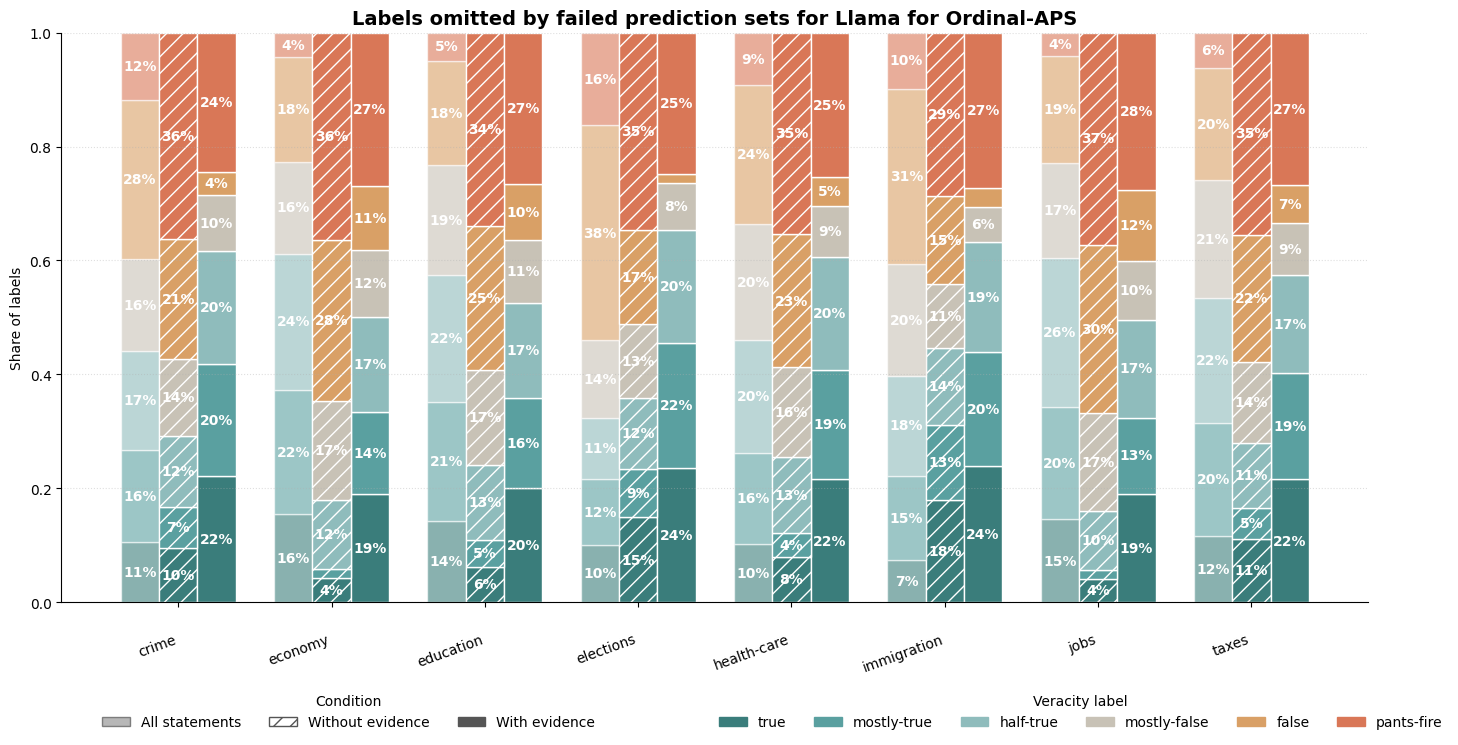

Saved: visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps_llama.png


: 

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv, output_path="visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps_llama.png"):
    categories = list(no_evidence_ordinalaps_llama_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_ordinalaps_llama_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_ordinalaps_llama_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_ordinalaps_llama_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets for Llama for Ordinal-APS", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_ordinalaps_llama_csv, with_evidence_ordinalaps_llama_csv)
print("Saved: visualisations_OrdinalAPS/failed_set_omissions_by_category_ordinalaps_llama.png")

# Fifth analysis: Show the spread of Ordinal-APS

### Prediction set such as ['true', 'false'] are not helpful, and while the size is 2, the actual sprea is ['true', 'mostly-true', 'half-true', 'mostly-false', 'false'] while has size 5.

Here, we calculate the real spread for both Llama and Mistral

In [ ]:
import ast
import pandas as pd
import numpy as np

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]
LABEL_TO_INDEX = {label: i for i, label in enumerate(LABEL_ORDER)}

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def real_spread(prediction_set):
    labels = parse_prediction_set(prediction_set)
    indices = [LABEL_TO_INDEX[l] for l in labels if l in LABEL_TO_INDEX]
    if not indices:
        return np.nan
    return (max(indices) - min(indices)) + 1  # inclusive span length

def add_spread(df):
    df = df.copy()
    df["real_spread"] = df["prediction_set"].apply(real_spread)
    return df

def summarize_spread(csv_dict, name):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "median_spread": df["real_spread"].median(),
            "pct_spread_ge_4": (df["real_spread"] >= 4).mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    print(f"\n{name}")
    print(out.to_string(index=False, formatters={
        "mean_spread": "{:.2f}".format,
        "median_spread": "{:.1f}".format,
        "pct_spread_ge_4": "{:.1%}".format,
    }))
    return out

# Llama
summarize_spread(no_evidence_ordinalaps_llama_csv, "Llama - no evidence")
summarize_spread(with_evidence_ordinalaps_llama_csv, "Llama - with evidence")

# Mistral
summarize_spread(no_evidence_ordinalaps_mistral_csv, "Mistral - no evidence")
summarize_spread(with_evidence_ordinalaps_mistral_csv, "Mistral - with evidence")


import matplotlib.pyplot as plt


def spread_and_coverage(csv_dict):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "coverage": df["is_covered"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    return out

def _plot_spread_panel(ax, categories, no_spread, with_spread, no_cov, with_cov,
                       title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_spread,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_spread,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, spread_val, cov_val):
        ax.text(
            xi + 0.03,
            spread_val + 0.05,
            f"{spread_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="#222",
        )
        ax.text(
            xi + 0.03,
            spread_val + 0.45,
            f"{cov_val * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=14,
            color="#666",
        )

    for xi, s, c in zip(x - width / 2, no_spread, no_cov):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_spread, with_cov):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average real spread")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                  loc="upper right", bbox_to_anchor=(1.0, 1.08))

def plot_real_spread_by_category(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
    output_path="visualisations_OrdinalAPS/real_spread_by_category_OrdinalAPS.png",
):
    llama_no = spread_and_coverage(no_evidence_ordinalaps_llama_csv)
    llama_w  = spread_and_coverage(with_evidence_ordinalaps_llama_csv)
    mist_no  = spread_and_coverage(no_evidence_ordinalaps_mistral_csv)
    mist_w   = spread_and_coverage(with_evidence_ordinalaps_mistral_csv)

    categories = llama_no["category"].tolist()

    llama_no_s = llama_no["mean_spread"].values
    llama_w_s  = llama_w["mean_spread"].values
    mist_no_s  = mist_no["mean_spread"].values
    mist_w_s   = mist_w["mean_spread"].values

    llama_no_c = llama_no["coverage"].values
    llama_w_c  = llama_w["coverage"].values
    mist_no_c  = mist_no["coverage"].values
    mist_w_c   = mist_w["coverage"].values

    y_max = max(llama_no_s.max(), llama_w_s.max(), mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_spread_panel(
        ax_top, categories,
        llama_no_s, llama_w_s, llama_no_c, llama_w_c,
        title="(a) Llama", show_legend=True, show_xticklabels=False
    )
    _plot_spread_panel(
        ax_bot, categories,
        mist_no_s, mist_w_s, mist_no_c, mist_w_c,
        title="(b) Mistral", show_legend=False, show_xticklabels=True
    )

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average real spread by category using Ordinal-APS",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_real_spread_by_category(
    no_evidence_ordinalaps_llama_csv,
    with_evidence_ordinalaps_llama_csv,
    no_evidence_ordinalaps_mistral_csv,
    with_evidence_ordinalaps_mistral_csv,
)